# 03 · State change & ablation

`process(StateChange)` lesions a population of units, observes the effect, and restores exactly — the mechanism behind induced-dyslexia experiments. This laptop-safe demo uses a small torch network so the intervention is fast and fully inspectable.


In [1]:
import warnings
warnings.filterwarnings('ignore', message='xarray subclass Score should explicitly define __slots__', category=FutureWarning)

import numpy as np, torch, torch.nn as nn
from brainscore_core.model_interface import (BrainScoreModel, StateChange,
    Selection, Perturbation)
from brainscore.perturbation import build_pytorch_ablation_fn
torch.manual_seed(0)
net = nn.Sequential(nn.Linear(8, 16), nn.ReLU(), nn.Linear(16, 4))
_ = net.eval()

## Wrap with a state_change_fn and ablate a population
Layer `'0'` is the first Linear (16 output units); we zero its first 8.

In [2]:
bs = BrainScoreModel(identifier='toy', model=net, region_layer_map={'R': '0'},
                     preprocessors={}, activations_model=None,
                     state_change_fn=build_pytorch_ablation_fn(net))
x = torch.randn(5, 8)
baseline = net(x).detach().numpy()
applied = bs.process(StateChange(kind='ablation',
             target=Selection(layer='0', indices=list(range(8))),
             perturbation=Perturbation(kind='zero')))
lesioned = net(x).detach().numpy()
print('handle:', applied.handle_id,
      '| output changed:', not np.allclose(baseline, lesioned))

handle: 0f3404c8-e024-45b3-97c0-36b878aa379b | output changed: True


## Visualize intact vs lesioned vs difference

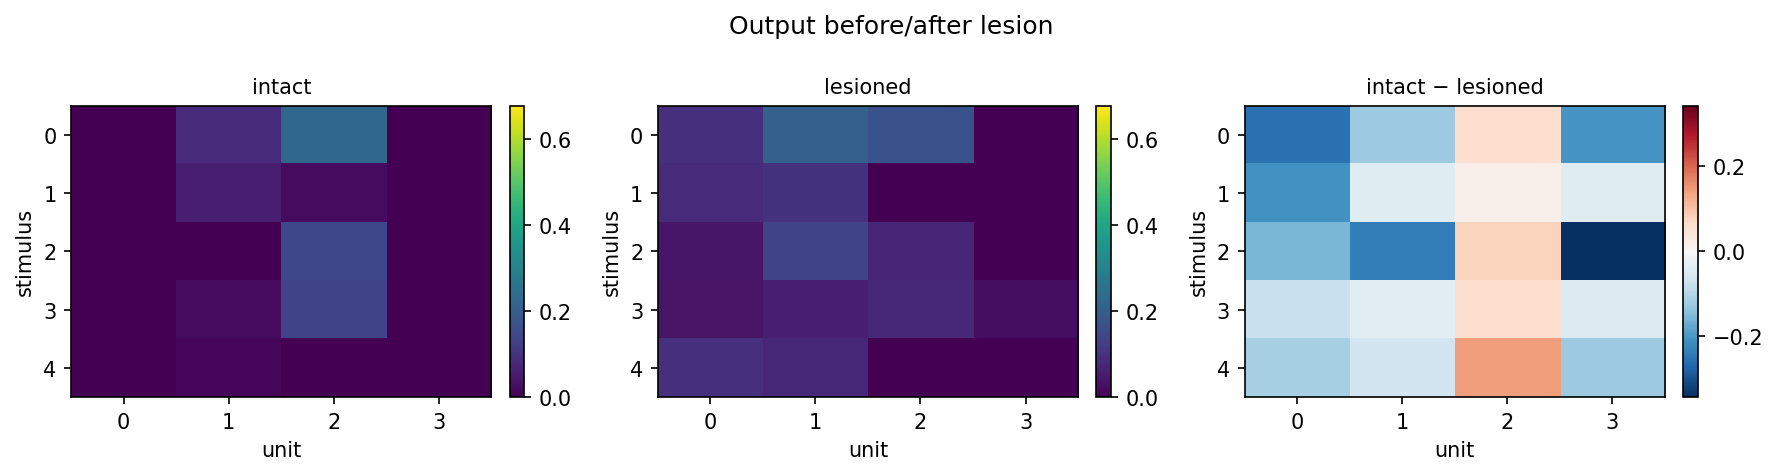

wrote plot: /var/folders/h6/g53mxg516n538136hh74630r0000gn/T/ablation_demo.png


In [3]:
from pathlib import Path
import tempfile
from IPython.display import Image, display
from brainscore.visualization import before_after_difference

out_png = Path(tempfile.gettempdir()) / 'ablation_demo.png'
# Show output-level effects; hooking intermediate activations would obscure the state-change contract.
before_after_difference(baseline, lesioned, out_png=str(out_png),
                        title='Output before/after lesion')
display(Image(str(out_png)))
print('wrote plot:', out_png)


## Restore exactly and confirm bit-for-bit recovery

In [4]:
bs.reset()
restored = net(x).detach().numpy()
print('restored == baseline:', np.allclose(restored, baseline))

restored == baseline: True


**Null for ablation:** ablating a *random* same-size population should produce a weaker effect than a curated (e.g. top-Cohen's-d) population. Use `brainscore_core.nulls.random_unit_subset` to pick the random set.